
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Punto 1

En el caso estático la ecuación a resolver es la ecuación de Laplace, pues $\partial{u} / \partial{t} = 0$.

In [52]:
def Diffusion2D(V_ini, dx2, dt, D):
    # u0 = V_ini.copy()
    u = V_ini.copy()

    # Usando slices para que vaya más rápido
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2]- 4*u0[1:-1, 1:-1])/dx2

    return u

def Laplace2D_FDM(V_ini,Niter):
    V0 = V_ini.copy()
    V = V_ini.copy()

    for _ in range(Niter):
        V[1:-1, 1:-1] = 0.25*(V0[2:, 1:-1] + V0[:-2, 1:-1] + V0[1:-1, 2:] + V0[1:-1, :-2])
        V0 = V

    return V

Tomó 0.04 segundos en hacer 1000 iteraciones.


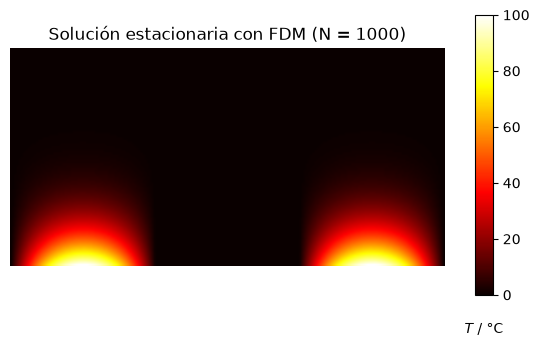

In [60]:
# Parámetros
a = 20
b = 10
D = 84 # mm^2 / s
f = lambda x: 100 * np.sin(3 * np.pi * x / a)

dx = dy = 0.1
nx, ny = int(a / dx), int(b / dy)

# Condiciones iniciales
u0 = np.zeros((ny, nx))
u0[-1, :] = f(np.linspace(0, a, nx))

steps = 1000

start = time.process_time()
u = Laplace2D_FDM(u0, steps)
end = time.process_time()

print(f"Tomó {end - start:.2f} segundos en hacer {steps} iteraciones.")

fig, ax = plt.subplots(figsize=(6,4) )

im = ax.imshow(u.copy(), cmap="hot", vmin=0, vmax=100, interpolation="bilinear",)
ax.set_axis_off()
ax.set_title(f"Solución estacionaria con FDM (N = {steps})")

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / °C", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

## Punto 2

La solución analítica para el caso estacionario viene dada por 
$$
u(x, y) = 100 \sin\left(\frac{3 \pi x}{a}\right) \displaystyle \frac{\sinh\left(\displaystyle \frac{3 \pi y}{a} \right)}{\sinh \left(\displaystyle \frac{3 \pi b}{a} \right)}.
$$
Espero el profesor confíe en que sí hice los cálculos. Como la condición de frontera es un seno, la serie se "muere" y queda únicamente un término, dejando una solución bastante cerrada.

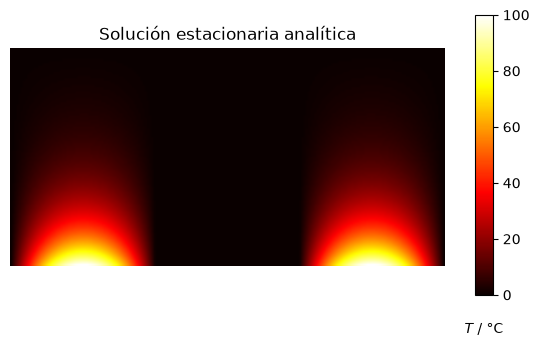

In [61]:
# Hacer el grid
cx = np.linspace(0, a, nx)
cy = np.linspace(0, b, ny)
x , y = np.meshgrid(cx, cy, indexing= 'ij')

T = lambda x, y: 100 * np.sin(3*np.pi*x/a) * np.sinh(3*np.pi*y/a) / np.sinh(3*np.pi*b/a)

u_an = T(x, y)

fig, ax = plt.subplots(figsize=(6,4))

im = ax.imshow(u_an.T, cmap="hot", vmin=0, vmax=100, interpolation="bilinear",)
ax.set_axis_off()
ax.set_title(f"Solución estacionaria analítica")

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / °C", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

Si uno se fija únicamente en las gráficas, son similares, aunque se alcanza a ver que en la solución analítica hay más difusión a lo largo de la placa que en la solución numérica. Veamos cuál es el error máximo entre estas.

In [51]:
diff_max = np.max(np.abs(u_an - u.T))
print(f"La máxima diferencia entre las dos mallas es de {diff_max:.2e}")

La máxima diferencia entre las dos mallas es de 1.12e+01


Un error del orden de 10 es bastante considerable. Sin embargo, hay que tener en cuenta que la malla numérica tomó menos de 0.05 segundos en calcularse; hacen falta muchas más iteraciones para tener la precisión correcta.

In [80]:
u0 = np.zeros((ny, nx))
u0[-1, :] = f(np.linspace(0, a, nx))
N = 8000
u_preciso = Laplace2D_FDM(u0, N)

diff_max = np.max(np.abs(u_an - u_preciso.T))
print(f"La máxima diferencia entre las dos mallas, con {N} iteraciones, es de {diff_max:.2e}")

La máxima diferencia entre las dos mallas, con 8000 iteraciones, es de 1.74e-01


## Punto 3

dt = 0.000030


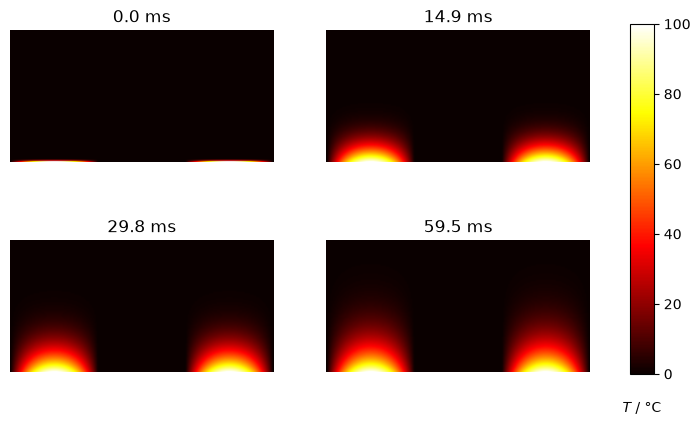

In [ ]:
# Parámetros
a = 20
b = 10
D = 84 # mm^2 / s
f = lambda x: 100 * np.sin(3 * np.pi * x / a)

dx = dy = 0.1
dx2 = dy2 = dx * dx
dt = dx2 * dy2 / (2 * D * (dx2 + dy2))
print(f"dt = {dt:f}")

nx, ny = int(a / dx), int(b / dy)

# Condiciones iniciales
u0 = np.zeros((ny, nx))
u0[-1, :] = f(np.linspace(0, a, nx))

steps = 2000 + 1
plotpoints = [0, 500, 1000, 2000]

u = u0.copy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,5))
fignum = 0

for n in range(steps):
    u = Diffusion2D(u0, dx2, dt, D)
    u0 = u.copy()
    if n in plotpoints:
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(
            u.copy(),
            cmap="hot",
            vmin=0,
            vmax=100,
            interpolation="bilinear",
        )
        ax.set_axis_off()
        ax.set_title("{:.1f} ms".format(n * dt * 1000))
        fignum += 1

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / °C", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

El _timestep_ es de $3 \times 10^{-5}$ segundos. Podemos ver que la difusión ocurre muy rápido, los cambios notorios ocurren en los primeros 15 ms. Luego de esto se sigue difundiendo la temperatura, pero en escalas menores, cerca de los 20 °C.

## Punto 4. Bonus

No sé si el notebook guarda dentro de su metadata el GIF. De no ser así, el código se demora un par de segundos para generar el archivo, pero no mucho, < 10 s.

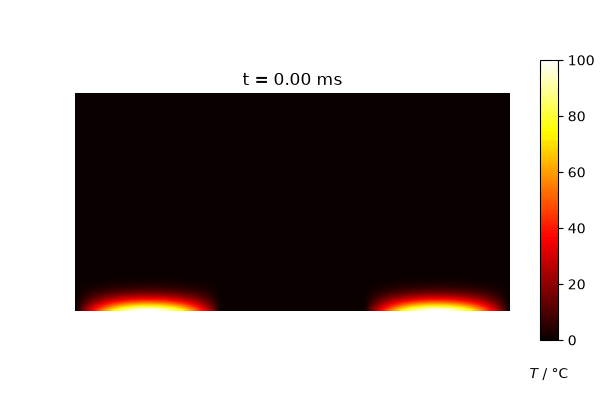

In [77]:
import matplotlib.animation as animation
from IPython.display import Image

fig, ax = plt.subplots(figsize=(6,4))

u0 = np.zeros((ny, nx))
u0[-1, :] = f(np.linspace(0, a, nx))
u = u0.copy()

im = ax.imshow(u, cmap="hot", vmin=0, vmax=100, interpolation="bilinear",)

skip_steps = 15

def update(frame):
    global u0

    # Para estabilidad del gif
    for _ in range(skip_steps):
        u = Diffusion2D(u0, dx2, dt, D)
        u0 = u.copy()

    im.set_data(u)
    current_time = frame * skip_steps * dt * 1000
    ax.set_title(f"t = {current_time:.2f} ms")
    return im,


ax.set_axis_off()

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / °C", labelpad=20)
fig.colorbar(im, cax=cbar_ax)

ani = animation.FuncAnimation(fig, update, frames=200, blit=True)

writer = animation.PillowWriter(fps=30, metadata=dict(artist='Me'), bitrate=1800)
ani.save('diffusion.gif', writer=writer)

plt.close(fig)

Image(filename='diffusion.gif')